In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

In [2]:
DATA_PATH = Path("D:/clg_project/AI-Financial-Wellness-Coach/data/master/final_master_transaction.csv")

df = pd.read_csv(DATA_PATH)

print("Dataset loaded successfully.")
print(f"Rows: {df.shape[0]}")
print(f"Columns: {df.shape[1]}")

Dataset loaded successfully.
Rows: 7000
Columns: 20


In [3]:
pd.set_option("display.max_columns", None)

display(df.head(10))

,transaction_id,transaction_date,transaction_time,merchant,description,amount,currency,payment_method,transaction_type,category,city,state,country,day,week,month,weekend,month_end,salary_week,festival_season
0,TXN000001,2018-01-01,09:22:10,Credit Card Bill Payment,Auto Debit Credit Card Bill Payment,4361.84,INR,Auto Debit,Debit,Bills,Bengaluru,Karnataka,India,1,1,1,0,0,1,0
1,TXN000002,2018-01-01,12:33:23,Zepto,UPI/Paytm/Zepto,1226.03,INR,UPI,Debit,Groceries,Bengaluru,Karnataka,India,1,1,1,0,0,1,0
2,TXN000003,2018-01-01,20:17:30,Ace Hardware India,POS Purchase Ace Hardware India,523.73,INR,Credit Card,Debit,Miscellaneous,Bengaluru,Karnataka,India,1,1,1,0,0,1,0
3,TXN000004,2018-01-01,21:33:19,Zepto,UPI/DR/623175732898/Zepto,1290.29,INR,UPI,Debit,Groceries,Indore,Madhya Pradesh,India,1,1,1,0,0,1,0
4,TXN000005,2018-01-02,08:43:33,House Rent Payment,NEFT Rent Payment,44800.94,INR,NEFT,Debit,Rent,Pune,Maharashtra,India,2,1,1,0,0,1,0
5,TXN000006,2018-01-02,11:44:19,Credit Card Bill Payment,Net Banking Payment Credit Card Bill Payment,2761.36,INR,Net Banking,Debit,Bills,Bengaluru,Karnataka,India,2,1,1,0,0,1,0
6,TXN000007,2018-01-02,12:17:48,Swiggy,UPI/Paytm/Swiggy,268.49,INR,UPI,Debit,Food,Bengaluru,Karnataka,India,2,1,1,0,0,1,0
7,TXN000008,2018-01-02,12:27:57,McDonald's India,UPI/DR/200262210949/McDonald's India,306.84,INR,UPI,Debit,Food,Bengaluru,Karnataka,India,2,1,1,0,0,1,0
8,TXN000009,2018-01-02,20:06:32,BookMyShow,UPI Payment BookMyShow,323.91,INR,UPI,Debit,Entertainment,Surat,Gujarat,India,2,1,1,0,0,1,0
9,TXN000010,2018-01-02,21:08:00,Ajio,POS Purchase Ajio,491.31,INR,Credit Card,Debit,Shopping,Nagpur,Maharashtra,India,2,1,1,0,0,1,0


In [4]:
print("Column names:")
for i, column in enumerate(df.columns, start=1):
    print(f"{i}. {column}")

Column names:
1. transaction_id
2. transaction_date
3. transaction_time
4. merchant
5. description
6. amount
7. currency
8. payment_method
9. transaction_type
10. category
11. city
12. state
13. country
14. day
15. week
16. month
17. weekend
18. month_end
19. salary_week
20. festival_season


In [5]:
print("\nColumn data types:")
print(df.dtypes)


Column data types:
transaction_id       object
transaction_date     object
transaction_time     object
merchant             object
description          object
amount              float64
currency             object
payment_method       object
transaction_type     object
category             object
city                 object
state                object
country              object
day                   int64
week                  int64
month                 int64
weekend               int64
month_end             int64
salary_week           int64
festival_season       int64
dtype: object


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7000 entries, 0 to 6999
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   transaction_id    7000 non-null   object 
 1   transaction_date  7000 non-null   object 
 2   transaction_time  7000 non-null   object 
 3   merchant          7000 non-null   object 
 4   description       7000 non-null   object 
 5   amount            7000 non-null   float64
 6   currency          7000 non-null   object 
 7   payment_method    7000 non-null   object 
 8   transaction_type  7000 non-null   object 
 9   category          7000 non-null   object 
 10  city              7000 non-null   object 
 11  state             7000 non-null   object 
 12  country           7000 non-null   object 
 13  day               7000 non-null   int64  
 14  week              7000 non-null   int64  
 15  month             7000 non-null   int64  
 16  weekend           7000 non-null   int64  


### Missing Values

In [7]:
missing = pd.DataFrame({
    "missing_count": df.isnull().sum(),
    "missing_percentage": (df.isnull().sum() / len(df) * 100).round(2)
})

missing = missing.sort_values(
    "missing_percentage",
    ascending=False
)

display(missing)

,missing_count,missing_percentage
transaction_id,0,0.0
transaction_date,0,0.0
salary_week,0,0.0
month_end,0,0.0
weekend,0,0.0
month,0,0.0
week,0,0.0
day,0,0.0
country,0,0.0
state,0,0.0


### Duplicate values

In [8]:
duplicate_count = df.duplicated().sum()

print(f"Completely duplicated rows: {duplicate_count}")

Completely duplicated rows: 0


In [9]:
if "transaction_id" in df.columns:
    duplicate_transaction_ids = df["transaction_id"].duplicated().sum()

    print(
        f"Duplicated transaction IDs: "
        f"{duplicate_transaction_ids}"
    )

Duplicated transaction IDs: 0


##### Rows = 7000
##### Columns = 20
##### We just need to change datatypes of columns 
##### there are no null values 
##### no duplicate values

### Date column inspection

In [10]:
print("Date data type:")
print(df["transaction_date"].dtype)

display(df["transaction_date"].head())

Date data type:
object


0    2018-01-01
1    2018-01-01
2    2018-01-01
3    2018-01-01
4    2018-01-02
Name: transaction_date, dtype: object

In [11]:
# copying date column for inspection

date_check = pd.to_datetime(
    df["transaction_date"],
    errors="coerce"
)

print("Invalid/unparseable dates:", date_check.isna().sum())

Invalid/unparseable dates: 0


In [12]:
print("Earliest transaction:")
print(date_check.min())

print("\nLatest transaction:")
print(date_check.max())

print(
    "Date range:",
    date_check.max() - date_check.min()
)

Earliest transaction:
2018-01-01 00:00:00

Latest transaction:
2019-11-10 00:00:00
Date range: 678 days 00:00:00


### Checking transaction types

In [13]:
print("Transaction types:")
display(
    df["transaction_type"]
    .value_counts(dropna=False)
)

Transaction types:


transaction_type
Debit     6810
Credit     190
Name: count, dtype: int64

In [14]:
transaction_type_percentage = (
    df["transaction_type"]
    .value_counts(normalize=True, dropna=False)
    .mul(100)
    .round(2)
)

display(transaction_type_percentage)

transaction_type
Debit     97.29
Credit     2.71
Name: proportion, dtype: float64

### Inspecting categories

In [15]:
print("Number of categories:")
print(df["category"].nunique())

print("\nCategory distribution:")
display(
    df["category"]
    .value_counts(dropna=False)
)

Number of categories:
13

Category distribution:


category
Bills            2059
Food             1328
Groceries         912
Shopping          550
Other             435
Fuel              423
Miscellaneous     358
Subscription      242
Salary            173
Entertainment     167
Rent              165
Insurance         152
Investment         36
Name: count, dtype: int64

In [16]:
category_percentage = (
    df["category"]
    .value_counts(normalize=True, dropna=False)
    .mul(100)
    .round(2)
)

display(category_percentage)

category
Bills            29.41
Food             18.97
Groceries        13.03
Shopping          7.86
Other             6.21
Fuel              6.04
Miscellaneous     5.11
Subscription      3.46
Salary            2.47
Entertainment     2.39
Rent              2.36
Insurance         2.17
Investment        0.51
Name: proportion, dtype: float64

### Inspecting description / merchant information

In [17]:
if "merchant" in df.columns:
    print("Unique merchants:")
    print(df["merchant"].nunique())

    display(
        df["merchant"]
        .value_counts()
        .head(20)
    )

Unique merchants:
99


merchant
Credit Card Bill Payment      693
DMart                         178
Airtel                        175
Reliance Fresh                167
House Rent Payment            165
Employer Salary Credit        163
Indian Oil                    162
Municipal Water Department    155
BigBasket                     146
Nature's Basket               143
HPCL                          143
Blinkit                       140
Zepto                         138
Jio                           137
Amazon India                  123
BPCL                          118
Cafe Coffee Day               117
Zomato                        117
Tata Power                    116
Myntra                        115
Name: count, dtype: int64

In [18]:
print("Unique descriptions:")
print(df["description"].nunique())

display(
    df["description"]
    .value_counts()
    .head(20)
)

Unique descriptions:
1176


description
Auto Debit Credit Card Bill Payment             369
Net Banking Payment Credit Card Bill Payment    273
NEFT Salary Credit                              163
Auto Debit Airtel                                85
Auto Debit Municipal Water Department            79
POS Purchase Amazon India                        70
Auto Debit Jio                                   67
Auto Debit Spotify                               60
Auto Debit Jio Fiber                             58
Auto Debit BSNL                                  57
NEFT Rent Payment                                56
UPI/Paytm/Zomato                                 55
Cash Withdrawal ATM                              53
POS Purchase Flipkart                            53
POS Purchase Myntra                              52
UPI/Paytm/Swiggy                                 50
Auto Debit BEST                                  48
Auto Debit Tata Power                            48
Auto Debit Bharat Gas                            47


### Inspecting the amount column

In [19]:
print(df["amount"].dtype)

display(df["amount"].head(20))

float64


0      4361.84
1      1226.03
2       523.73
3      1290.29
4     44800.94
5      2761.36
6       268.49
7       306.84
8       323.91
9       491.31
10      144.85
11     2801.01
12     5154.86
13      524.73
14      332.16
15     2855.13
16      478.83
17    42338.57
18     3363.40
19      154.29
Name: amount, dtype: float64

In [20]:
display(df["amount"].head(20))

0      4361.84
1      1226.03
2       523.73
3      1290.29
4     44800.94
5      2761.36
6       268.49
7       306.84
8       323.91
9       491.31
10      144.85
11     2801.01
12     5154.86
13      524.73
14      332.16
15     2855.13
16      478.83
17    42338.57
18     3363.40
19      154.29
Name: amount, dtype: float64

In [21]:
display(df["amount"].describe())

count      7000.000000
mean       4989.675896
std       13768.784894
min          30.740000
25%         489.030000
50%        1382.480000
75%        3620.717500
max      240125.840000
Name: amount, dtype: float64

### Largest transactions

In [22]:
print("Largest transactions:")
display(
    df.nlargest(20, "amount")[
        [c for c in ["user_id", "date", "description",
                     "amount", "category"]
         if c in df.columns]
    ]
)

Largest transactions:


,description,amount,category
5966,NEFT Salary Credit,240125.84,Salary
5584,NEFT Salary Credit,238163.14,Salary
6246,NEFT Salary Credit,225266.29,Salary
6442,NEFT Salary Credit,222120.88,Salary
6614,NEFT Salary Credit,203265.19,Salary
6536,NEFT Salary Credit,202071.67,Salary
6902,NEFT Salary Credit,196659.20,Salary
6906,NEFT Salary Credit,195608.36,Salary
6242,NEFT Salary Credit,188574.21,Salary
5181,NEFT Salary Credit,177208.79,Salary


### Check negative amounts

In [23]:
if pd.api.types.is_numeric_dtype(df["amount"]):
    print("Negative amounts:", (df["amount"] < 0).sum())
    print("Zero amounts:", (df["amount"] == 0).sum())

Negative amounts: 0
Zero amounts: 0


### Inspecting amount distribution

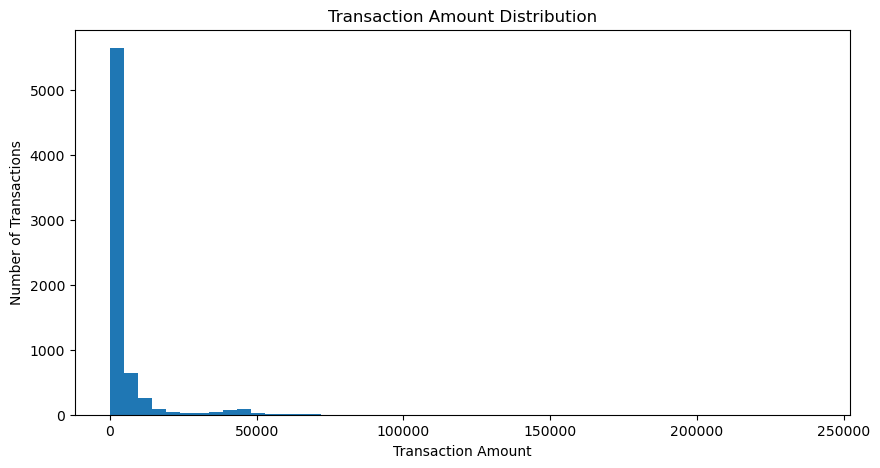

In [24]:
plt.figure(figsize=(10, 5))

plt.hist(
    df["amount"].dropna(),
    bins=50
)

plt.xlabel("Transaction Amount")
plt.ylabel("Number of Transactions")
plt.title("Transaction Amount Distribution")

plt.show()

### Inspect amount percentiles

In [25]:
percentiles = df["amount"].quantile(
    [0.01, 0.05, 0.25, 0.50, 0.75, 0.90, 0.95, 0.99, 0.999]
)

display(percentiles)

0.010       101.55990
0.050       152.24500
0.250       489.03000
0.500      1382.48000
0.750      3620.71750
0.900      9844.57400
0.950     20933.14200
0.990     49660.98020
0.999    195609.41084
Name: amount, dtype: float64

### Checking relationships between columns

In [26]:
important_columns = [
    c for c in [
        "transaction_date",
        'merchant',
        "description",
        "amount",
        "transaction_type",
        "category",
    ]
    if c in df.columns
]

display(df[important_columns].head(20))

,transaction_date,merchant,description,amount,transaction_type,category
0,2018-01-01,Credit Card Bill Payment,Auto Debit Credit Card Bill Payment,4361.84,Debit,Bills
1,2018-01-01,Zepto,UPI/Paytm/Zepto,1226.03,Debit,Groceries
2,2018-01-01,Ace Hardware India,POS Purchase Ace Hardware India,523.73,Debit,Miscellaneous
3,2018-01-01,Zepto,UPI/DR/623175732898/Zepto,1290.29,Debit,Groceries
4,2018-01-02,House Rent Payment,NEFT Rent Payment,44800.94,Debit,Rent
5,2018-01-02,Credit Card Bill Payment,Net Banking Payment Credit Card Bill Payment,2761.36,Debit,Bills
6,2018-01-02,Swiggy,UPI/Paytm/Swiggy,268.49,Debit,Food
7,2018-01-02,McDonald's India,UPI/DR/200262210949/McDonald's India,306.84,Debit,Food
8,2018-01-02,BookMyShow,UPI Payment BookMyShow,323.91,Debit,Entertainment
9,2018-01-02,Ajio,POS Purchase Ajio,491.31,Debit,Shopping


### Checking category × transaction type

In [27]:
if "category" in df.columns and "transaction_type" in df.columns:

    category_type = pd.crosstab(
        df["category"],
        df["transaction_type"]
    )

    display(category_type)

transaction_type,Credit,Debit
category,,
Bills,0,2059
Entertainment,0,167
Food,0,1328
Fuel,0,423
Groceries,0,912
Insurance,0,152
Investment,0,36
Miscellaneous,0,358
Other,0,435


### Transactions per day

In [28]:
date_check = pd.to_datetime(
    df["transaction_date"],
    errors="coerce"
)

daily_transactions = (
    date_check
    .dt.date
    .value_counts()
    .sort_index()
)

display(daily_transactions.head(20))

transaction_date
2018-01-01    11
2018-01-02    13
2018-01-03     8
2018-01-04    10
2018-01-05    15
2018-01-06     8
2018-01-07     5
2018-01-08     8
2018-01-09    10
2018-01-10    20
2018-01-11     9
2018-01-12    10
2018-01-13     8
2018-01-14     5
2018-01-15     7
2018-01-16     5
2018-01-17     8
2018-01-18     6
2018-01-19     7
2018-01-20    13
Name: count, dtype: int64

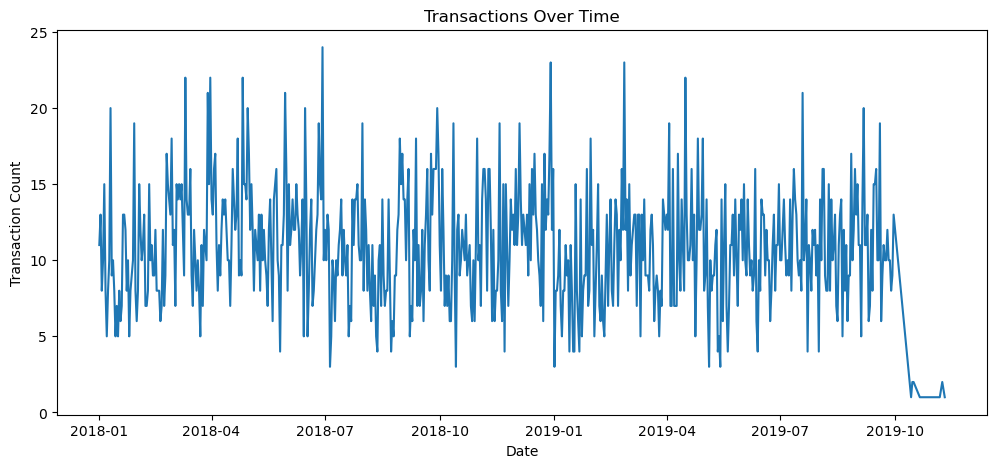

In [29]:
plt.figure(figsize=(12, 5))

daily_transactions.plot()

plt.xlabel("Date")
plt.ylabel("Transaction Count")
plt.title("Transactions Over Time")

plt.show()

### Daily spending

In [30]:
temp = df.copy()

temp["inspection_date"] = pd.to_datetime(
    temp["transaction_date"],
    errors="coerce"
)

daily_spending = (
    temp.groupby(
        temp["inspection_date"].dt.date
    )["amount"]
    .sum()
)

display(daily_spending.head(20))

inspection_date
2018-01-01     77103.28
2018-01-02     99601.47
2018-01-03     28836.12
2018-01-04     52272.13
2018-01-05    117374.98
2018-01-06     24714.74
2018-01-07      2693.69
2018-01-08     19897.49
2018-01-09     20414.07
2018-01-10     54559.78
2018-01-11     71324.93
2018-01-12     66942.58
2018-01-13      6670.86
2018-01-14     93023.05
2018-01-15     20203.81
2018-01-16      9788.11
2018-01-17      7886.48
2018-01-18      9684.86
2018-01-19     96521.64
2018-01-20     89147.17
Name: amount, dtype: float64

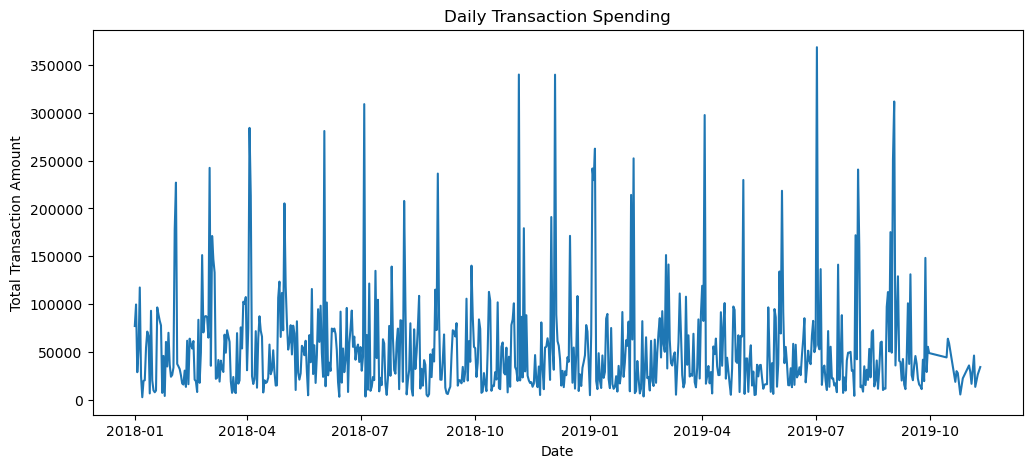

In [31]:
plt.figure(figsize=(12, 5))

daily_spending.plot()

plt.xlabel("Date")
plt.ylabel("Total Transaction Amount")
plt.title("Daily Transaction Spending")

plt.show()

### Summary about data inspection

In [32]:
print("=" * 60)
print("ANOMALY DETECTION DATASET INSPECTION SUMMARY")
print("=" * 60)

print(f"Rows: {len(df)}")
print(f"Columns: {len(df.columns)}")

if "user_id" in df.columns:
    print(f"Unique users: {df['user_id'].nunique()}")
else:
    print("Unique users: user_id column not available")

print(
    f"Duplicate rows: {df.duplicated().sum()}"
)

print(
    f"Missing values: {df.isna().sum().sum()}"
)

if "date" in df.columns:
    temp_date = pd.to_datetime(
        df["date"],
        errors="coerce"
    )

    print(f"Invalid dates: {temp_date.isna().sum()}")
    print(f"Earliest date: {temp_date.min()}")
    print(f"Latest date: {temp_date.max()}")

if "category" in df.columns:
    print(
        f"Unique categories: "
        f"{df['category'].nunique()}"
    )

if "transaction_type" in df.columns:
    print(
        f"Transaction types: "
        f"{df['transaction_type'].nunique()}"
    )

if "amount" in df.columns:
    print(
        f"Amount data type: "
        f"{df['amount'].dtype}"
    )

print("=" * 60)

ANOMALY DETECTION DATASET INSPECTION SUMMARY
Rows: 7000
Columns: 20
Unique users: user_id column not available
Duplicate rows: 0
Missing values: 0
Unique categories: 13
Transaction types: 2
Amount data type: float64
